# Gene × modality matrix (one score per gene)

As suggested by our supervisor we create one single table with the 50 PAM50 genes as rows and, for each of the 4 models, two columns —
expression and methylation (8 columns total). Then one combined score per gene, ranked.

### How each cell is built and how the saturation problem is solved.

For a given model and modality we take, per gene, its **best feature** of that modality (the RNA
feature, or the strongest CpG), then **rank the 50 genes** by that value and scale to 0–1
(1 = top gene, 0 = not used). The important detail: we rank among **50 genes**, not among the
hundreds of raw CpG features — that is what "solves the saturation problem of the methylation data".

### The methylation correction

Only the two multi-omics models have methylation features; the two mRNA-only models leave those
cells empty. So expression evidence comes from 4 models and methylation from 2. To stop
expression from dominating just by count, we average within each modality first
(expression_mean over 4 models, methylation_mean over 2), and only then combine.

combined = expression_mean + methylation_mean - the sum rewards genes important via *either or
both* data types. Genes are ranked by this.


## Load the four importance tables

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TABLES = Path("../results/tables")
FIGURES = Path("../results/figures"); FIGURES.mkdir(parents=True, exist_ok=True)

MODELS = {
    "LASSO_mRNA":       "feature_importance_lasso_mrna.csv",
    "LASSO_multiomics": "feature_importance_lasso_multiomics.csv",
    "NN_mRNA":          "feature_importance_nn_mrna.csv",
    "NN_integrated":    "feature_importance_nn_integrated.csv",
}
tables = {m: pd.read_csv(TABLES / f) for m, f in MODELS.items()}
ALL_GENES = sorted(set().union(*[set(df["gene"]) for df in tables.values()]))
print("Genes:", len(ALL_GENES))

Genes: 50


## Build the 8 columns

`modality_score` aggregates a gene to its best feature of one modality in one model, then ranks the
50 genes (0–1). A model without that modality (mRNA-only + methylation) returns empty cells.

In [3]:
def modality_score(df, modality):
    sub = df[df["modality"] == modality]
    if sub.empty:
        return None                                   # e.g. methylation in an mRNA-only model
    g = sub.groupby("gene")["importance"].max().reindex(ALL_GENES).fillna(0.0)
    score = g.rank(pct=True)                           # rank among the 50 genes -> 0..1
    score[g <= 0] = 0.0                                # a gene never used scores 0
    return score

cols = {}
for m, df in tables.items():
    for mod, label in [("RNA", "expression"), ("METH", "methylation")]:
        s = modality_score(df, mod)
        cols[f"{m}__{label}"] = s if s is not None else pd.Series(np.nan, index=ALL_GENES)

matrix = pd.DataFrame(cols, index=ALL_GENES)
matrix.round(2).head()

,LASSO_mRNA__expression,LASSO_mRNA__methylation,LASSO_multiomics__expression,LASSO_multiomics__methylation,NN_mRNA__expression,NN_mRNA__methylation,NN_integrated__expression,NN_integrated__methylation
ACTR3B,0.56,NaN,0.76,0.38,0.24,NaN,0.40,0.34
ANLN,0.80,NaN,0.00,0.56,0.34,NaN,0.42,0.28
BAG1,0.20,NaN,0.82,0.90,0.26,NaN,0.52,0.08
BCL2,0.48,NaN,0.78,0.62,0.46,NaN,0.26,0.42
BIRC5,0.70,NaN,0.00,0.40,0.92,NaN,0.50,0.76


## Modality means, combined score, ranking

In [4]:
expr_cols = [c for c in matrix.columns if c.endswith("expression")]
meth_cols = [c for c in matrix.columns if c.endswith("methylation")]

matrix["expression_mean"] = matrix[expr_cols].mean(axis=1)     # over 4 models
matrix["methylation_mean"] = matrix[meth_cols].mean(axis=1)    # over 2 models (empty cells ignored)
matrix["combined"] = matrix["expression_mean"] + matrix["methylation_mean"]

matrix = matrix.sort_values("combined", ascending=False)
matrix["rank"] = np.arange(1, len(matrix) + 1)

matrix.to_csv(TABLES / "gene_modality_matrix.csv")
matrix[["expression_mean", "methylation_mean", "combined", "rank"]].head(15).round(2)

,expression_mean,methylation_mean,combined,rank
KRT5,0.84,0.75,1.59,1
SFRP1,0.44,0.91,1.36,2
MAPT,0.75,0.57,1.32,3
ESR1,0.30,0.99,1.28,4
MYC,0.58,0.68,1.27,5
NUF2,0.80,0.45,1.25,6
MLPH,0.44,0.81,1.25,7
CDC6,0.55,0.66,1.21,8
ERBB2,0.38,0.82,1.20,9
CENPF,0.62,0.57,1.18,10


## Figure: top 15 genes, split into the two modality contributions

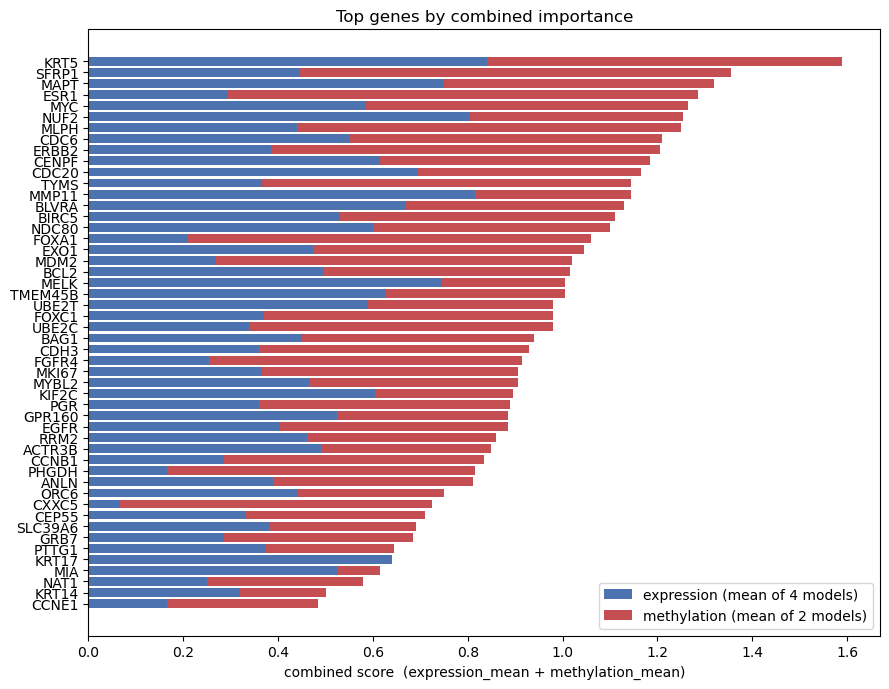

In [6]:
d = matrix.head(50).iloc[::-1]
plt.figure(figsize=(9, 7))
plt.barh(d.index, d["expression_mean"], color="#4C72B0", label="expression (mean of 4 models)")
plt.barh(d.index, d["methylation_mean"], left=d["expression_mean"],
         color="#C44E52", label="methylation (mean of 2 models)")
plt.xlabel("combined score  (expression_mean + methylation_mean)")
plt.title("Top genes by combined importance")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES / "gene_modality_matrix_top15.png", dpi=300)
plt.show()

## Summary

Output: 
- gene_modality_matrix.csv

Each bar shows how a gene's score splits between expression (blue) and methylation (red): a gene high
on both is important across data types, one dominated by a single colour is a one-modality only feature.
The methylation columns are properly spread (not saturated) because genes are ranked among the 50,
and the 4-vs-2-model asymmetry is handled by averaging within each modality before summing.
